# Actividad 8 — SVD: Compresión de Imágenes

**Matemáticas Aplicadas para Ciencia de los Datos** · Clase 4 (Producto Interno, Proyecciones
Ortogonales, Diagonalización, PCA, SVD)

**Contexto.** Una imagen en escala de grises se representa como una matriz $A \in \mathbb{R}^{m \times n}$,
donde cada entrada $A_{ij}$ es la intensidad del píxel $(i,j)$.

**Objetivo.** Aplicar la SVD para comprimir una imagen y analizar el *trade-off* entre la calidad de la
imagen reconstruida y la cantidad de información (valores singulares) que retenemos.

| # | Paso de la actividad | Estado |
|---|------|--------|
| 1 | Cargar una imagen en escala de grises y convertirla en matriz $A$ | este notebook |
| 2 | Calcular la SVD completa $A = U\Sigma V^{T}$ | este notebook |
| 3 | Reconstruir con los primeros $k$ componentes: $A_k = U(:,1{:}k)\,\Sigma(1{:}k,1{:}k)\,V(:,1{:}k)^{T}$ | este notebook |
| 4 | Visualizar $A_k$ y comparar con la original | este notebook |
| 5 | Scree plot de los valores singulares (¿dónde está el "codo"?) | pendiente |
| 6 | Ratio de compresión vs. calidad para cada $k$ | pendiente |

### Conceptos de la clase que se aplican aquí

| Concepto | Diapositiva | Dónde se usa |
|---|---|---|
| Producto interno y norma inducida, $\|v\| = \sqrt{\langle v,v\rangle}$ | 5–6 | verificación de ortonormalidad |
| Ángulo y ortogonalidad, $\cos\theta = \frac{\langle u,v\rangle}{\|u\|\|v\|}$ | 6 | ángulo entre vectores singulares |
| Producto interno de Frobenius, $\langle A,B\rangle_F = \operatorname{tr}(A^TB)$ | 8 | métrica de error entre imágenes |
| Bases ortonormales y proyección ortogonal | 27–28, 33 | puente hacia el Punto 3 |
| Teorema Espectral ($A^TA$ simétrica $\Rightarrow$ diagonalizable ortogonalmente) | 66, 88 | algoritmo manual de la SVD |
| Teorema de la SVD, formas completa y reducida | 92–93 | Punto 2 |
| Interpretación geométrica: rotación → escalamiento → rotación | 94–96 | esfera $\to$ elipsoide |
| Algoritmo de cálculo vía $A^TA$: $\sigma_i=\sqrt{\lambda_i}$, $u_i = \frac{1}{\sigma_i}Av_i$ | 97–100 | implementación propia y validación |
| Suma de matrices de rango 1 y Eckart–Young | 108 | capas $\sigma_i u_i v_i^T$ |
| Varianza explicada y scree plot | 109 | preparación de los puntos 5–6 |

## 0. Configuración e importación de librerías

In [1]:
import os
import glob

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Opciones de presentación
np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["image.cmap"] = "gray"      # las imágenes se muestran en escala de grises
plt.rcParams["image.interpolation"] = "nearest"

print("NumPy      :", np.__version__)
print("Pillow     :", Image.__version__)
print("Directorio :", os.getcwd())

NumPy      : 2.4.4
Pillow     : 12.1.1
Directorio : /home/claude/work


---
## Herramientas del curso: producto interno y norma

Antes de tocar la imagen, implementamos las herramientas de la **Clase 4** que vamos a usar para *verificar*
todo lo demás. La idea del curso es que el producto interno es lo que introduce la geometría
(longitud, ángulo, ortogonalidad) en un espacio vectorial (diapositivas 4–6).

**En $\mathbb{R}^n$** (diapositiva 7) usamos el producto punto y su norma inducida:

$$\langle x, y\rangle = x^{T}y, \qquad \|x\|_2 = \sqrt{\langle x,x\rangle},
\qquad \cos\theta = \frac{\langle x,y\rangle}{\|x\|\,\|y\|}$$

**En el espacio de matrices $\mathbb{R}^{m\times n}$** (diapositiva 8) usamos el **producto interno de
Frobenius** y su norma inducida:

$$\langle A, B\rangle_F = \operatorname{tr}(A^{T}B) = \sum_{i=1}^{m}\sum_{j=1}^{n} A_{ij}B_{ij},
\qquad \|A\|_F = \sqrt{\langle A,A\rangle_F}$$

La diapositiva lo dice explícitamente: sirve para *"medir la similitud entre dos imágenes o el error de una
aproximación matricial"*. Es exactamente la métrica que necesitamos para el Punto 6, y la que aparece en el
teorema de Eckart–Young (diapositiva 108).

In [2]:
def producto_interno(x, y):
    """Producto punto en R^n:  <x, y> = x^T y   (diapositiva 7)."""
    return float(x @ y)


def norma(x):
    """Norma inducida por el producto punto: ||x|| = sqrt(<x,x>)   (diapositiva 6)."""
    return np.sqrt(producto_interno(x, x))


def angulo(x, y, en_grados=True):
    """Ángulo entre dos vectores: cos(theta) = <x,y> / (||x|| ||y||)   (diapositiva 6)."""
    coseno = producto_interno(x, y) / (norma(x) * norma(y))
    coseno = np.clip(coseno, -1.0, 1.0)          # protege contra error de redondeo
    theta = np.arccos(coseno)
    return np.degrees(theta) if en_grados else theta


def producto_interno_frobenius(A, B):
    """Producto interno de Frobenius: <A,B>_F = trace(A^T B)   (diapositiva 8)."""
    return float(np.trace(A.T @ B))


def norma_frobenius(A):
    """Norma inducida por el producto interno de Frobenius: ||A||_F = sqrt(<A,A>_F)."""
    return np.sqrt(producto_interno_frobenius(A, A))


# --- Comprobación de las implementaciones con el ejemplo de la diapositiva 7 ---
u = np.array([1.0, -2.0, 2.0])
v = np.array([3.0,  1.0, -1.0])
print("Ejemplo de la diapositiva 7:  u = (1,-2,2),  v = (3,1,-1)")
print(f"  <u,v>   = {producto_interno(u, v):.4f}   (esperado: -1)")
print(f"  ||u||   = {norma(u):.4f}   (esperado: 3)")
print(f"  ||v||   = {norma(v):.4f}   (esperado: sqrt(11) = {np.sqrt(11):.4f})")
print(f"  cos(th) = {producto_interno(u,v)/(norma(u)*norma(v)):.4f}   (esperado: -0.1005 -> ángulo obtuso)")
print(f"  ángulo  = {angulo(u, v):.2f}°")

M = np.array([[1.0, 2.0], [3.0, 4.0]])
print("\nProducto interno de Frobenius (diapositiva 8):")
print(f"  <M,M>_F = {producto_interno_frobenius(M, M):.4f}   (suma de cuadrados: 1+4+9+16 = 30)")
print(f"  ||M||_F = {norma_frobenius(M):.6f}   vs np.linalg.norm = {np.linalg.norm(M):.6f}")

Ejemplo de la diapositiva 7:  u = (1,-2,2),  v = (3,1,-1)
  <u,v>   = -1.0000   (esperado: -1)
  ||u||   = 3.0000   (esperado: 3)
  ||v||   = 3.3166   (esperado: sqrt(11) = 3.3166)
  cos(th) = -0.1005   (esperado: -0.1005 -> ángulo obtuso)
  ángulo  = 95.77°

Producto interno de Frobenius (diapositiva 8):
  <M,M>_F = 30.0000   (suma de cuadrados: 1+4+9+16 = 30)
  ||M||_F = 5.477226   vs np.linalg.norm = 5.477226


---
## Punto 1 — Cargar una imagen en escala de grises y convertirla en la matriz $A$

La imagen se convierte a **un solo canal** (escala de grises, modo `"L"` de Pillow). El resultado es una
matriz $A \in \mathbb{R}^{m\times n}$ (alto $\times$ ancho) cuyas entradas $A_{ij}$ son intensidades de píxel,
tal como plantea el enunciado de la actividad.

Dos decisiones que conviene dejar explícitas:

- **Normalización:** trabajamos con valores en $[0,1]$ (`float64`) en lugar de enteros $\{0,\dots,255\}$.
  Es solo un cambio de escala ($A_{[0,1]} = A_{[0,255]}/255$), así que **no altera la estructura de la SVD**:
  los vectores singulares $u_i, v_i$ son idénticos y los valores singulares quedan divididos por 255
  (porque $\Sigma$ es lineal en $A$).
- **Redimensionado:** limitamos el lado mayor a `MAX_LADO` píxeles. La SVD completa cuesta
  $O(mn\cdot\min(m,n))$ y `full_matrices=True` construye $U$ de $m\times m$ y $V$ de $n\times n$; con
  imágenes grandes eso se vuelve costoso en tiempo y memoria.

In [3]:
RUTA_IMAGEN = "imagenb&w.jpg"   # imagen de trabajo
MAX_LADO    = 512               # el lado mayor se reduce a este tamaño (None = no redimensionar)

_EXTENSIONES = ("*.png", "*.jpg", "*.jpeg", "*.bmp", "*.tif", "*.tiff", "*.webp")
disponibles = sorted({p for e in _EXTENSIONES for p in glob.glob(e)})
print("Imágenes encontradas en la carpeta:", disponibles if disponibles else "(ninguna)")

assert os.path.exists(RUTA_IMAGEN), f"No se encontró '{RUTA_IMAGEN}'. Elige una de: {disponibles}"

Imágenes encontradas en la carpeta: ['imagenb&w.jpg']


In [4]:
def cargar_imagen_gris(ruta, max_lado=None, normalizar=True):
    """Carga una imagen, la convierte a escala de grises y devuelve la matriz A.

    Parámetros
    ----------
    ruta : str
        Ruta del archivo de imagen.
    max_lado : int o None
        Si se indica, se redimensiona manteniendo la relación de aspecto para que
        el lado mayor no supere este valor.
    normalizar : bool
        True  -> A con valores float en [0, 1]
        False -> A con valores float en [0, 255]

    Retorna
    -------
    A : ndarray (m, n) de float64
    info : dict con metadatos de la carga
    """
    img = Image.open(ruta)
    modo_original, tam_original = img.mode, img.size   # size = (ancho, alto)

    # 1) Conversión a escala de grises: un único canal de luminancia.
    #    Pillow usa la fórmula ITU-R 601-2:  L = 0.299 R + 0.587 G + 0.114 B
    img = img.convert("L")

    # 2) Redimensionado opcional (LANCZOS conserva bien el detalle al reducir)
    if max_lado is not None:
        ancho, alto = img.size
        escala = max_lado / max(ancho, alto)
        if escala < 1:
            nuevo = (max(1, round(ancho * escala)), max(1, round(alto * escala)))
            img = img.resize(nuevo, Image.LANCZOS)

    # 3) Imagen -> matriz NumPy. float64 porque la SVD trabaja en punto flotante.
    A = np.asarray(img, dtype=np.float64)
    if normalizar:
        A = A / 255.0

    info = {
        "ruta": ruta,
        "modo_original": modo_original,
        "tamano_original": tam_original,
        "tamano_final": img.size,
        "normalizada": normalizar,
    }
    return A, info


A, info = cargar_imagen_gris(RUTA_IMAGEN, max_lado=MAX_LADO, normalizar=True)
m, n = A.shape

for clave, valor in info.items():
    print(f"{clave:>16}: {valor}")

            ruta: imagenb&w.jpg
   modo_original: RGB
 tamano_original: (2829, 2122)
    tamano_final: (512, 384)
     normalizada: True


In [5]:
# --- Propiedades de la matriz A -------------------------------------------
print("Matriz A")
print("-" * 52)
print(f"  Forma (m x n)       : {m} x {n}   (filas = alto, columnas = ancho)")
print(f"  Tipo de dato        : {A.dtype}")
print(f"  Nº de entradas      : {A.size:,}   (= m·n, el costo de almacenar A 'en crudo')")
print(f"  Rango de valores    : [{A.min():.4f}, {A.max():.4f}]   (0 = negro, 1 = blanco)")
print(f"  Intensidad media    : {A.mean():.4f}")
print(f"  Desviación estándar : {A.std():.4f}")
print(f"  Memoria (float64)   : {A.nbytes/1024:.1f} KB")
print(f"  Rango máx. posible  : min(m, n) = {min(m, n)}")
print(f"  Rango real de A     : {np.linalg.matrix_rank(A)}")
print()
print("Esquina superior izquierda de A (5x5):")
print(A[:5, :5])

Matriz A
----------------------------------------------------
  Forma (m x n)       : 384 x 512   (filas = alto, columnas = ancho)
  Tipo de dato        : float64
  Nº de entradas      : 196,608   (= m·n, el costo de almacenar A 'en crudo')
  Rango de valores    : [0.0000, 1.0000]   (0 = negro, 1 = blanco)
  Intensidad media    : 0.3574
  Desviación estándar : 0.2108
  Memoria (float64)   : 1536.0 KB
  Rango máx. posible  : min(m, n) = 384
  Rango real de A     : 384

Esquina superior izquierda de A (5x5):
[[0.4039 0.4118 0.4118 0.4078 0.4078]
 [0.4039 0.4039 0.4    0.4039 0.4039]
 [0.3961 0.3961 0.4    0.4    0.4039]
 [0.3922 0.3961 0.3961 0.4    0.4039]
 [0.3922 0.3961 0.3922 0.3961 0.4   ]]


In [6]:
# --- La imagen vista como un vector de un espacio con producto interno ----
# Usamos el producto interno de Frobenius de la diapositiva 8.
normaA = norma_frobenius(A)
print(f"<A,A>_F = trace(A^T A) = {producto_interno_frobenius(A, A):.4f}")
print(f"||A||_F = sqrt(<A,A>_F) = {normaA:.4f}   (comprobación np.linalg.norm: {np.linalg.norm(A):.4f})")
print()

# El producto interno permite medir SIMILITUD entre imágenes (diapositiva 8):
# cos(theta) entre A y versiones modificadas de A, usando la geometría de Frobenius.
def coseno_frobenius(X, Y):
    return producto_interno_frobenius(X, Y) / (norma_frobenius(X) * norma_frobenius(Y))

A_espejo   = A[:, ::-1]                       # reflejo horizontal
A_invertida = 1.0 - A                         # negativo de la imagen
ruido = np.random.default_rng(0).normal(0, 0.1, A.shape)
A_ruidosa  = np.clip(A + ruido, 0, 1)         # imagen con ruido gaussiano

print("Similitud (coseno de Frobenius) entre A y otras imágenes:")
print(f"  A       vs A          : {coseno_frobenius(A, A):.4f}   (mismo 'vector' -> ángulo 0°)")
print(f"  A       vs A ruidosa  : {coseno_frobenius(A, A_ruidosa):.4f}")
print(f"  A       vs A espejo   : {coseno_frobenius(A, A_espejo):.4f}")
print(f"  A       vs 1 - A      : {coseno_frobenius(A, A_invertida):.4f}   (negativo de la imagen)")
print()
print(f"Error de una aproximación, medido con la norma inducida:")
print(f"  ||A - A_ruidosa||_F = {norma_frobenius(A - A_ruidosa):.4f}"
      f"   ({100*norma_frobenius(A - A_ruidosa)/normaA:.2f} % relativo)")
print()
print("Esta es la métrica de error que usaremos en los puntos 3-6 para comparar A con A_k.")

<A,A>_F = trace(A^T A) = 33854.7025
||A||_F = sqrt(<A,A>_F) = 183.9965   (comprobación np.linalg.norm: 183.9965)

Similitud (coseno de Frobenius) entre A y otras imágenes:
  A       vs A          : 1.0000   (mismo 'vector' -> ángulo 0°)
  A       vs A ruidosa  : 0.9739
  A       vs A espejo   : 0.8099
  A       vs 1 - A      : 0.6600   (negativo de la imagen)

Error de una aproximación, medido con la norma inducida:
  ||A - A_ruidosa||_F = 42.8643   (23.30 % relativo)

Esta es la métrica de error que usaremos en los puntos 3-6 para comparar A con A_k.


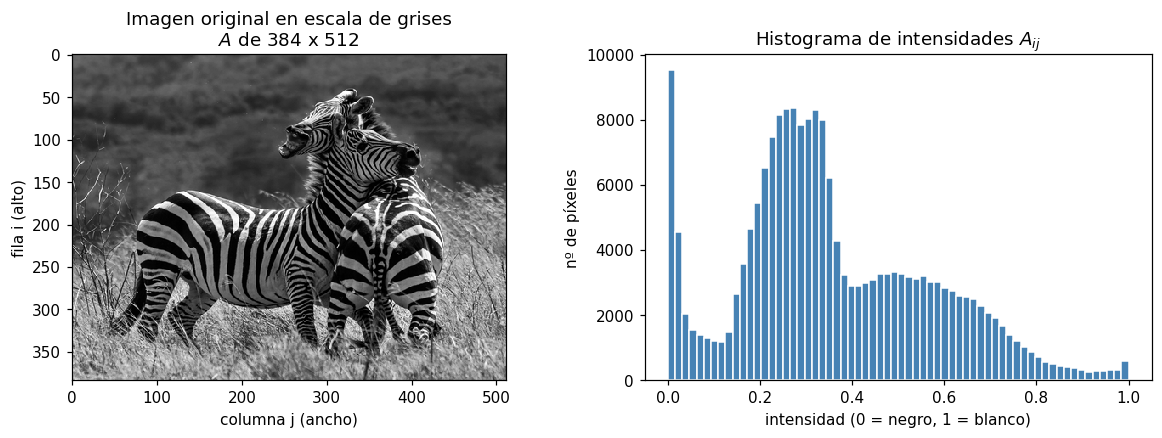

In [7]:
# --- Visualización de la imagen y su distribución de intensidades ---------
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].imshow(A, vmin=0, vmax=1)
axes[0].set_title(f"Imagen original en escala de grises\n$A$ de {m} x {n}")
axes[0].set_xlabel("columna j (ancho)")
axes[0].set_ylabel("fila i (alto)")

axes[1].hist(A.ravel(), bins=64, range=(0, 1), color="steelblue", edgecolor="white")
axes[1].set_title("Histograma de intensidades $A_{ij}$")
axes[1].set_xlabel("intensidad (0 = negro, 1 = blanco)")
axes[1].set_ylabel("nº de píxeles")

plt.tight_layout()
plt.show()

### Resultado del Punto 1

La imagen quedó representada como una matriz real $A \in \mathbb{R}^{m \times n}$ con entradas en $[0,1]$:
cada **fila** es una línea horizontal de píxeles y cada **columna** una línea vertical. Guardarla "en crudo"
cuesta $m\cdot n$ números — ese es el valor de referencia contra el que mediremos el ratio de compresión en
el Punto 6.

Además dotamos al espacio $\mathbb{R}^{m\times n}$ del **producto interno de Frobenius**, con lo cual una
imagen es literalmente un vector de un espacio con producto interno: podemos hablar de su norma
$\|A\|_F$, de la distancia $\|A - B\|_F$ entre dos imágenes y hasta del ángulo entre ellas.

Nótese que el **rango real de $A$** es cercano a $\min(m,n)$: algebraicamente la imagen "usa" casi todas
las dimensiones disponibles. La SVD nos mostrará que, aunque el rango sea alto, la *energía* está
concentrada en muy pocas direcciones — y ahí es donde vive la compresión.

---
## Punto 2 — SVD completa de $A$: $A = U\,\Sigma\,V^{T}$

### Teorema de la SVD (diapositiva 92)

Sea $A$ una matriz de $m\times n$ con rango $r$. Entonces $A$ se puede factorizar como

$$A = U\,\Sigma\,V^{T}$$

donde

| Factor | Dimensión | Propiedad |
|--------|-----------|-----------|
| $U$ | $m \times m$ | **ortogonal**; sus columnas $\{u_1,\dots,u_m\}$ son los **vectores singulares izquierdos** |
| $\Sigma$ | $m \times n$ | "diagonal": únicas entradas no nulas en la diagonal, $\sigma_1 \ge \sigma_2 \ge \dots \ge \sigma_r > 0$ |
| $V$ | $n \times n$ | **ortogonal**; sus columnas $\{v_1,\dots,v_n\}$ son los **vectores singulares derechos** |

La SVD **existe y es única salvo signos** en los vectores singulares, para *cualquier* matriz. Esto es lo
que la hace más general que la diagonalización ortogonal $A = QDQ^{T}$, que exige que $A$ sea simétrica
(diapositivas 88 y 91): nuestra matriz de imagen no es simétrica y ni siquiera es cuadrada.

> ⚠️ **Convención de NumPy:** `np.linalg.svd` devuelve `Vt`, que ya es $V^{T}$ (no $V$). Por eso la
> reconstrucción es `U @ Sigma @ Vt`, y los vectores $v_i$ (columnas de $V$) son las **filas** de `Vt`.

In [8]:
# --- Cálculo de la SVD completa (Paso 2 del enunciado) --------------------
U, s, Vt = np.linalg.svd(A, full_matrices=True)

# 's' es un VECTOR con los min(m, n) valores singulares.
# Construimos la matriz Sigma de m x n (diapositiva 92) para escribir A = U @ Sigma @ Vt.
Sigma = np.zeros((m, n), dtype=np.float64)
np.fill_diagonal(Sigma, s)

V = Vt.T          # matriz V (n x n), con la notación V(:, i) = v_i del enunciado
r = np.linalg.matrix_rank(A)

print("SVD completa (full_matrices=True)")
print("-" * 56)
print(f"  A      : {A.shape}")
print(f"  U      : {U.shape}   ortogonal m x m")
print(f"  s      : {s.shape}   vector con los min(m,n) valores singulares")
print(f"  Sigma  : {Sigma.shape}   'diagonal' m x n")
print(f"  V^T    : {Vt.shape}   ortogonal n x n")
print(f"  rango r: {r}")
print()
print("Comprobación de dimensiones del producto:")
print(f"  ({U.shape[0]}x{U.shape[1]}) @ ({Sigma.shape[0]}x{Sigma.shape[1]}) @ "
      f"({Vt.shape[0]}x{Vt.shape[1]}) -> ({U.shape[0]}x{Vt.shape[1]})  ==  A {A.shape}")
print()
print("Bloque superior izquierdo de Sigma (5x5):")
print(Sigma[:5, :5])

SVD completa (full_matrices=True)
--------------------------------------------------------
  A      : (384, 512)
  U      : (384, 384)   ortogonal m x m
  s      : (384,)   vector con los min(m,n) valores singulares
  Sigma  : (384, 512)   'diagonal' m x n
  V^T    : (512, 512)   ortogonal n x n
  rango r: 384

Comprobación de dimensiones del producto:
  (384x384) @ (384x512) @ (512x512) -> (384x512)  ==  A (384, 512)

Bloque superior izquierdo de Sigma (5x5):
[[165.8257   0.       0.       0.       0.    ]
 [  0.      27.404    0.       0.       0.    ]
 [  0.       0.      23.2915   0.       0.    ]
 [  0.       0.       0.      21.7581   0.    ]
 [  0.       0.       0.       0.      18.2716]]


In [9]:
# --- ¿Se cumple A = U·Sigma·V^T? (error medido con la norma de Frobenius) --
A_reconstruida = U @ Sigma @ Vt
E = A - A_reconstruida

print("Verificación de la factorización")
print("-" * 56)
print(f"  np.allclose(A, U·Sigma·V^T)      : {np.allclose(A, A_reconstruida)}")
print(f"  ||A - U·Sigma·V^T||_F            : {norma_frobenius(E):.3e}")
print(f"  Error relativo ||E||_F / ||A||_F : {norma_frobenius(E)/norma_frobenius(A):.3e}")
print(f"  Error absoluto máximo            : {np.abs(E).max():.3e}")
print()
print("  Los errores son del orden de la precisión de máquina (~1e-16),")
print("  así que la igualdad se cumple exactamente salvo redondeo.")

Verificación de la factorización
--------------------------------------------------------
  np.allclose(A, U·Sigma·V^T)      : True
  ||A - U·Sigma·V^T||_F            : 3.140e-13
  Error relativo ||E||_F / ||A||_F : 1.707e-15
  Error absoluto máximo            : 2.831e-14

  Los errores son del orden de la precisión de máquina (~1e-16),
  así que la igualdad se cumple exactamente salvo redondeo.


In [10]:
# --- Ortogonalidad de U y V vista con el producto interno (diapositivas 5-6, 28) ---
# Una base es ORTONORMAL si  <u_i, u_j> = 1 si i=j,  0 si i!=j  (diapositiva 28).
print("Producto interno entre los primeros vectores singulares izquierdos u_i:")
print(f"  {'':6} " + " ".join(f"{'u'+str(j+1):>9}" for j in range(4)))
for i in range(4):
    fila = " ".join(f"{producto_interno(U[:, i], U[:, j]):9.2e}" for j in range(4))
    print(f"  {'u'+str(i+1):>6} " + fila)

print()
print("Es decir: cada u_i es unitario y ortogonal a los demás. En ángulos (diapositiva 6):")
for (i, j) in [(0, 0), (0, 1), (0, 2), (1, 2)]:
    print(f"  ángulo(u_{i+1}, u_{j+1}) = {angulo(U[:, i], U[:, j]):8.4f}°")

print()
print("Verificación matricial de la ortogonalidad (U^T U = I, V^T V = I):")
print(f"  max |U^T U - I_m| = {np.abs(U.T @ U - np.eye(m)).max():.3e}")
print(f"  max |V^T V - I_n| = {np.abs(V.T @ V - np.eye(n)).max():.3e}")
print()
print("Y los valores singulares cumplen lo que pide el teorema:")
print(f"  sigma_i >= 0                    : {bool(np.all(s >= 0))}")
print(f"  orden decreciente s1 >= s2 >= ...: {bool(np.all(np.diff(s) <= 1e-12))}")

Producto interno entre los primeros vectores singulares izquierdos u_i:
                u1        u2        u3        u4
      u1  1.00e+00  9.54e-18  5.20e-18 -8.32e-17
      u2  9.54e-18  1.00e+00 -4.25e-17  2.93e-16
      u3  5.20e-18 -4.25e-17  1.00e+00  1.84e-16
      u4 -8.32e-17  2.93e-16  1.84e-16  1.00e+00

Es decir: cada u_i es unitario y ortogonal a los demás. En ángulos (diapositiva 6):
  ángulo(u_1, u_1) =   0.0000°
  ángulo(u_1, u_2) =  90.0000°
  ángulo(u_1, u_3) =  90.0000°
  ángulo(u_2, u_3) =  90.0000°

Verificación matricial de la ortogonalidad (U^T U = I, V^T V = I):
  max |U^T U - I_m| = 2.680e-15
  max |V^T V - I_n| = 3.553e-15

Y los valores singulares cumplen lo que pide el teorema:
  sigma_i >= 0                    : True
  orden decreciente s1 >= s2 >= ...: True


### Interpretación geométrica (diapositivas 94–96)

La SVD dice que **cualquier** transformación lineal $T(x) = Ax$ se descompone en tres acciones:

1. **Rotación/reflexión en la entrada** ($V^{T}$): alinea $x$ con las direcciones principales de entrada $v_i$.
2. **Escalamiento a lo largo de los ejes** ($\Sigma$): estira el eje $i$ por el factor $\sigma_i$. Esta acción
   **transforma la esfera unitaria en un elipsoide**.
3. **Rotación/reflexión en la salida** ($U$): orienta el elipsoide en el espacio de llegada; los $u_i$ son
   sus ejes principales.

Todo esto se resume en una única identidad, la misma que aparece en el algoritmo de la diapositiva 100:

$$A v_i = \sigma_i u_i$$

Es decir: la dirección de entrada $v_i$ se transforma en la dirección de salida $u_i$, estirada por $\sigma_i$.

In [11]:
# --- Verificación de A v_i = sigma_i u_i ----------------------------------
print("Comprobación de  A·v_i = sigma_i·u_i  para los primeros vectores singulares:")
print(f"  {'i':>3} | {'sigma_i':>10} | {'||A v_i - sigma_i u_i||':>24}")
print(f"  {'-'*3}-+-{'-'*10}-+-{'-'*24}")
for i in range(5):
    v_i = V[:, i]
    residual = norma(A @ v_i - s[i] * U[:, i])
    print(f"  {i+1:>3} | {s[i]:10.4f} | {residual:24.3e}")

Comprobación de  A·v_i = sigma_i·u_i  para los primeros vectores singulares:
    i |    sigma_i |  ||A v_i - sigma_i u_i||
  ----+------------+-------------------------
    1 |   165.8257 |                9.411e-14
    2 |    27.4040 |                1.246e-13
    3 |    23.2915 |                4.658e-14
    4 |    21.7581 |                6.002e-14
    5 |    18.2716 |                2.985e-14


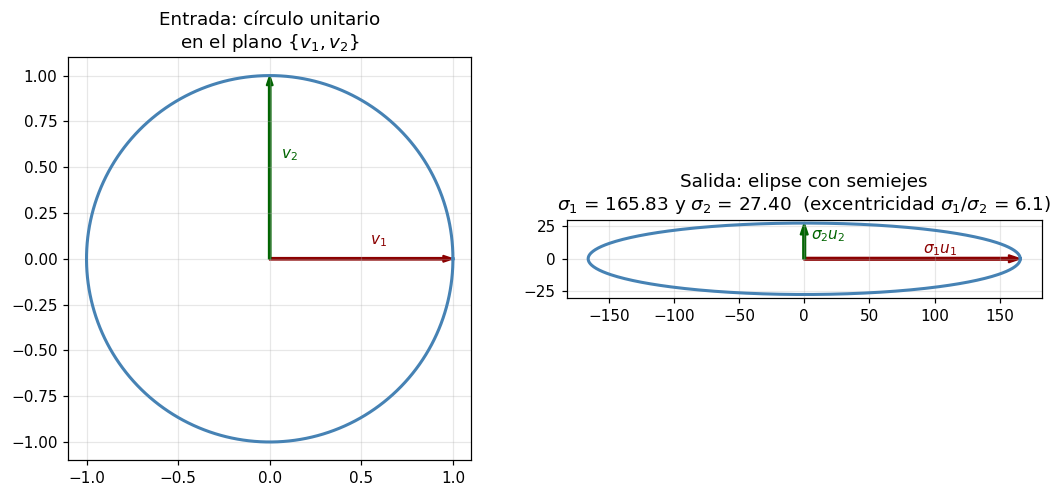

Semieje mayor medido : 165.8257   (sigma_1 = 165.8257)
Semieje menor medido : 27.4038   (sigma_2 = 27.4040)


In [12]:
# --- La esfera unitaria se convierte en un elipsoide (diapositivas 94-96) --
# Tomamos el círculo unitario del plano generado por v1 y v2:
#     x(t) = cos(t)·v1 + sin(t)·v2      ->      A·x(t) = sigma1·cos(t)·u1 + sigma2·sin(t)·u2
# En las coordenadas de la base {u1, u2}, la imagen es una elipse de semiejes sigma1 y sigma2.
t = np.linspace(0, 2*np.pi, 400)
X = np.outer(np.cos(t), V[:, 0]) + np.outer(np.sin(t), V[:, 1])   # círculo unitario en R^n
Y = X @ A.T                                                        # su imagen bajo A

coord_entrada = np.column_stack([X @ V[:, 0], X @ V[:, 1]])        # coords en la base {v1, v2}
coord_salida  = np.column_stack([Y @ U[:, 0], Y @ U[:, 1]])        # coords en la base {u1, u2}

fig, axes = plt.subplots(1, 2, figsize=(10, 4.6))

axes[0].plot(coord_entrada[:, 0], coord_entrada[:, 1], lw=2, color="steelblue")
axes[0].arrow(0, 0, 1, 0, color="darkred", width=0.012, length_includes_head=True)
axes[0].arrow(0, 0, 0, 1, color="darkgreen", width=0.012, length_includes_head=True)
axes[0].text(0.55, 0.08, "$v_1$", color="darkred")
axes[0].text(0.06, 0.55, "$v_2$", color="darkgreen")
axes[0].set_title("Entrada: círculo unitario\nen el plano $\\{v_1, v_2\\}$")
axes[0].set_aspect("equal"); axes[0].grid(alpha=0.3)

axes[1].plot(coord_salida[:, 0], coord_salida[:, 1], lw=2, color="steelblue")
axes[1].arrow(0, 0, s[0], 0, color="darkred", width=0.012*s[0], length_includes_head=True)
axes[1].arrow(0, 0, 0, s[1], color="darkgreen", width=0.012*s[0], length_includes_head=True)
axes[1].text(s[0]*0.55, s[1]*0.15, "$\\sigma_1 u_1$", color="darkred")
axes[1].text(s[0]*0.03, s[1]*0.55, "$\\sigma_2 u_2$", color="darkgreen")
axes[1].set_title("Salida: elipse con semiejes\n"
                  f"$\\sigma_1$ = {s[0]:.2f} y $\\sigma_2$ = {s[1]:.2f}"
                  f"  (excentricidad $\\sigma_1/\\sigma_2$ = {s[0]/s[1]:.1f})")
axes[1].set_aspect("equal"); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Los semiejes de la elipse son exactamente sigma_1 y sigma_2
print(f"Semieje mayor medido : {np.abs(coord_salida[:, 0]).max():.4f}   (sigma_1 = {s[0]:.4f})")
print(f"Semieje menor medido : {np.abs(coord_salida[:, 1]).max():.4f}   (sigma_2 = {s[1]:.4f})")

### El algoritmo de cálculo de la SVD (diapositivas 97–100)

El enunciado permite usar `svd` de librería, pero implementemos también el algoritmo visto en clase para
**verificar que entendemos de dónde salen $U$, $\Sigma$ y $V$**:

1. **Construir $A^{T}A$** ($n\times n$, siempre **simétrica y semidefinida positiva**) y hallar sus autovalores
   $\lambda_1 \ge \dots \ge \lambda_n \ge 0$. Por el **Teorema Espectral** (diapositiva 66), esta matriz es
   ortogonalmente diagonalizable: $A^{T}A = QDQ^{T}$.
2. **Valores singulares:** $\sigma_i = \sqrt{\lambda_i}$, colocados en la diagonal de $\Sigma$.
3. **Vectores singulares derechos:** los autovectores ortonormales de $A^{T}A$ son las columnas de $V$,
   $(A^{T}A)\,v_i = \lambda_i v_i$.
4. **Vectores singulares izquierdos:** $u_i = \dfrac{1}{\sigma_i}A v_i$ para $\sigma_i \neq 0$; si hace falta
   la $U$ completa, se completa la base con Gram–Schmidt.

Primero validamos la implementación reproduciendo el **Ejemplo 1** de las diapositivas 101–106.

In [13]:
def svd_desde_gram(A):
    """SVD calculada con el algoritmo de las diapositivas 97-100 (vía A^T A).

    Retorna
    -------
    U_hat  : (m, r)  vectores singulares izquierdos, u_i = A v_i / sigma_i
    sigma  : (n,)    valores singulares en orden decreciente (sigma_i = sqrt(lambda_i))
    V      : (n, n)  vectores singulares derechos (autovectores de A^T A) como columnas
    r      : int     rango numérico
    """
    m, n = A.shape

    # Paso 1: A^T A es simétrica y semidefinida positiva -> Teorema Espectral.
    #         np.linalg.eigh está pensada justamente para matrices simétricas.
    G = A.T @ A
    lam, V = np.linalg.eigh(G)

    # eigh devuelve los autovalores en orden ASCENDENTE: los invertimos.
    orden = np.argsort(lam)[::-1]
    lam, V = lam[orden], V[:, orden]
    lam = np.clip(lam, 0.0, None)        # limpia autovalores ~ -1e-17 por redondeo

    # Paso 2: sigma_i = sqrt(lambda_i)
    sigma = np.sqrt(lam)

    # Rango numérico: se decide sobre los AUTOVALORES, no sobre los sigma_i.
    # (A^T A eleva al cuadrado el número de condición, así que los lambda nulos
    #  aparecen como ~ eps·lambda_1 y sus raíces cuadradas son mucho mayores.)
    tol = max(m, n) * np.finfo(float).eps * lam[0]
    r = min(int(np.sum(lam > tol)), min(m, n))

    # Pasos 3 y 4: V ya está; u_i = (1/sigma_i)·A·v_i
    U_hat = (A @ V[:, :r]) / sigma[:r]

    return U_hat, sigma, V, r


# --- Validación con el Ejemplo 1 de las diapositivas 101-106 --------------
A_ej = np.array([[3.0, 1.0],
                 [2.0, 2.0],
                 [1.0, 3.0]])

print("Ejemplo 1 de clase:  A = [[3,1],[2,2],[1,3]]")
print("\nPaso 1 -> A^T A =")
print(A_ej.T @ A_ej, "   (esperado: [[14,10],[10,14]])")

U_ej, sig_ej, V_ej, r_ej = svd_desde_gram(A_ej)

print(f"\nPaso 2 -> autovalores de A^T A: {np.round(sig_ej**2, 6)}   (esperado: 24 y 4)")
print(f"          valores singulares    : {np.round(sig_ej, 6)}")
print(f"          esperado              : [2*sqrt(6), 2] = [{2*np.sqrt(6):.6f}, 2.000000]")
print(f"\nPaso 3 -> V (columnas v_i), esperado ±(1/sqrt2)[[1,1],[1,-1]]:")
print(np.round(V_ej, 4))
print(f"\nPaso 4 -> U_hat (columnas u_i = A v_i / sigma_i):")
print(np.round(U_ej, 4))
print(f"          1/sqrt(3) = {1/np.sqrt(3):.4f},  1/sqrt(2) = {1/np.sqrt(2):.4f}")
print("\n  u_1 = (1/sqrt3)(1,1,1) y u_2 = ±(1/sqrt2)(1,0,-1), tal como en la diapositiva 105.")
print("  El signo global de un par (u_i, v_i) puede invertirse: la SVD es única SALVO SIGNOS")
print("  (diapositiva 92), y NumPy y nuestro cálculo pueden elegir convenciones distintas.")
print(f"\nError de reconstrucción ||A - U·Sigma·V^T||_F = "
      f"{norma_frobenius(A_ej - U_ej @ np.diag(sig_ej[:r_ej]) @ V_ej[:, :r_ej].T):.3e}")

Ejemplo 1 de clase:  A = [[3,1],[2,2],[1,3]]

Paso 1 -> A^T A =
[[14. 10.]
 [10. 14.]]    (esperado: [[14,10],[10,14]])

Paso 2 -> autovalores de A^T A: [24.  4.]   (esperado: 24 y 4)
          valores singulares    : [4.899 2.   ]
          esperado              : [2*sqrt(6), 2] = [4.898979, 2.000000]

Paso 3 -> V (columnas v_i), esperado ±(1/sqrt2)[[1,1],[1,-1]]:
[[ 0.7071 -0.7071]
 [ 0.7071  0.7071]]

Paso 4 -> U_hat (columnas u_i = A v_i / sigma_i):
[[ 0.5774 -0.7071]
 [ 0.5774  0.    ]
 [ 0.5774  0.7071]]
          1/sqrt(3) = 0.5774,  1/sqrt(2) = 0.7071

  u_1 = (1/sqrt3)(1,1,1) y u_2 = ±(1/sqrt2)(1,0,-1), tal como en la diapositiva 105.
  El signo global de un par (u_i, v_i) puede invertirse: la SVD es única SALVO SIGNOS
  (diapositiva 92), y NumPy y nuestro cálculo pueden elegir convenciones distintas.

Error de reconstrucción ||A - U·Sigma·V^T||_F = 9.421e-16


In [14]:
# --- El mismo algoritmo aplicado a la imagen, comparado con np.linalg.svd --
U_g, s_g, V_g, r_g = svd_desde_gram(A)
k = min(m, n)

dif = np.abs(s_g[:k] - s)

print("Algoritmo de clase (vía A^T A)  vs  np.linalg.svd")
print("-" * 58)
print(f"  Rango numérico detectado      : {r_g}   (np.linalg.matrix_rank: {r})")
print(f"  Máx. diferencia |sigma_i|      : {dif.max():.3e}")
print(f"  Diferencia relativa (top 20)   : {(dif[:20]/s[:20]).max():.3e}")
print(f"  Diferencia relativa (cola i>300): {(dif[300:k]/s[300:k]).max():.3e}")
print(f"  Ortogonalidad de U:  vía A^T A  -> {np.abs(U_g.T @ U_g - np.eye(r_g)).max():.3e}")
print(f"                       np.svd     -> {np.abs(U.T @ U - np.eye(m)).max():.3e}")
rec_g = U_g @ np.diag(s_g[:r_g]) @ V_g[:, :r_g].T
print(f"  ||A - reconstruida||_F/||A||_F : {norma_frobenius(A - rec_g)/norma_frobenius(A):.3e}")
print()
print("Observación importante:")
print("  Los valores singulares GRANDES coinciden con precisión de máquina, pero la COLA")
print("  pierde varios dígitos. La razón: formar A^T A eleva al cuadrado el número de")
print("  condición, así que se pierde aproximadamente la mitad de los dígitos significativos.")
print("  Por eso las librerías (LAPACK, detrás de np.linalg.svd) NO usan este algoritmo:")
print("  trabajan directamente sobre A por bidiagonalización. El método de A^T A es la")
print("  vía CONCEPTUAL correcta (y la que se usa a mano), pero no la numéricamente óptima.")

Algoritmo de clase (vía A^T A)  vs  np.linalg.svd
----------------------------------------------------------
  Rango numérico detectado      : 384   (np.linalg.matrix_rank: 384)
  Máx. diferencia |sigma_i|      : 2.740e-12
  Diferencia relativa (top 20)   : 1.061e-15
  Diferencia relativa (cola i>300): 1.163e-10
  Ortogonalidad de U:  vía A^T A  -> 1.037e-09
                       np.svd     -> 2.680e-15
  ||A - reconstruida||_F/||A||_F : 2.463e-12

Observación importante:
  Los valores singulares GRANDES coinciden con precisión de máquina, pero la COLA
  pierde varios dígitos. La razón: formar A^T A eleva al cuadrado el número de
  condición, así que se pierde aproximadamente la mitad de los dígitos significativos.
  Por eso las librerías (LAPACK, detrás de np.linalg.svd) NO usan este algoritmo:
  trabajan directamente sobre A por bidiagonalización. El método de A^T A es la
  vía CONCEPTUAL correcta (y la que se usa a mano), pero no la numéricamente óptima.


### Forma completa vs. forma reducida (diapositiva 93)

| Forma | $U$ | $\Sigma$ | $V^{T}$ |
|---|---|---|---|
| **Completa** (*full SVD*) | $m\times m$ | $m\times n$ | $n\times n$ |
| **Reducida** (*thin SVD*) | $\hat U$: $m\times r$ | $\hat\Sigma$: $r\times r$ | $\hat V^{T}$: $r\times n$ |

Las columnas de $U$ más allá de la $r$-ésima multiplican filas nulas de $\Sigma$: **no aportan nada** a la
reconstrucción. La forma reducida guarda solo lo que realmente interviene, y es la que trunca el Punto 3.

In [15]:
# --- Forma completa vs. reducida ------------------------------------------
U_hat  = U[:, :r]          # m x r
Sig_hat = np.diag(s[:r])   # r x r
Vt_hat = Vt[:r, :]         # r x n

rec_hat = U_hat @ Sig_hat @ Vt_hat

print(f"{'':22}{'Completa':>16}{'Reducida (thin)':>20}")
print("-" * 58)
print(f"{'U':22}{str(U.shape):>16}{str(U_hat.shape):>20}")
print(f"{'Sigma':22}{str(Sigma.shape):>16}{str(Sig_hat.shape):>20}")
print(f"{'V^T':22}{str(Vt.shape):>16}{str(Vt_hat.shape):>20}")
print(f"{'Nº de números':22}{U.size+Sigma.size+Vt.size:>16,}{U_hat.size+r+Vt_hat.size:>20,}")
print(f"{'Memoria (KB)':22}{(U.nbytes+Sigma.nbytes+Vt.nbytes)/1024:>16.1f}"
      f"{(U_hat.nbytes+s[:r].nbytes+Vt_hat.nbytes)/1024:>20.1f}")
print()
print(f"Matriz A original: {A.size:,} números ({A.nbytes/1024:.1f} KB)")
print(f"||A - U_hat·Sigma_hat·V_hat^T||_F / ||A||_F = "
      f"{norma_frobenius(A - rec_hat)/norma_frobenius(A):.3e}   (reconstrucción exacta)")
print()
print("Nota: guardar la SVD SIN truncar ocupa MÁS que la propia imagen. La compresión no")
print("viene de factorizar, sino de QUEDARSE CON k << r componentes (Puntos 3 y 6).")

                              Completa     Reducida (thin)
----------------------------------------------------------
U                           (384, 384)          (384, 384)
Sigma                       (384, 512)          (384, 384)
V^T                         (512, 512)          (384, 512)
Nº de números                  606,208             344,448
Memoria (KB)                    4736.0              2691.0

Matriz A original: 196,608 números (1536.0 KB)
||A - U_hat·Sigma_hat·V_hat^T||_F / ||A||_F = 1.790e-15   (reconstrucción exacta)

Nota: guardar la SVD SIN truncar ocupa MÁS que la propia imagen. La compresión no
viene de factorizar, sino de QUEDARSE CON k << r componentes (Puntos 3 y 6).


### Valores singulares, energía y varianza explicada (diapositivas 108–109)

La SVD se puede escribir como una **suma de matrices de rango 1** (diapositiva 108):

$$A = \sum_{i=1}^{r}\sigma_i\,u_i v_i^{T}$$

Cada término es una "capa" de la imagen. Como las bases $\{u_i\}$ y $\{v_i\}$ son ortonormales, esas capas
son ortogonales entre sí respecto al producto interno de Frobenius, y por lo tanto la energía se **suma**:

$$\|A\|_F^{2} = \langle A,A\rangle_F = \sum_{i=1}^{r}\sigma_i^{2}$$

Eso justifica la definición de **varianza explicada** de la diapositiva 109:

$$\text{Varianza explicada por } k \;=\; \frac{\sum_{i=1}^{k}\sigma_i^{2}}{\sum_{i=1}^{r}\sigma_i^{2}}$$

In [16]:
# --- Energía y varianza explicada (diapositiva 109) -----------------------
energia_total = np.sum(s**2)
varianza_explicada = np.cumsum(s**2) / energia_total     # acumulada

print("Identidad de Parseval / Frobenius:")
print(f"  ||A||_F^2         = {norma_frobenius(A)**2:.6f}")
print(f"  suma de sigma_i^2 = {energia_total:.6f}")
print(f"  diferencia        = {abs(norma_frobenius(A)**2 - energia_total):.3e}")
print()
print(f"Nº de valores singulares : {len(s)}")
print(f"sigma_1 (máximo)         : {s[0]:.4f}")
print(f"sigma_r (mínimo no nulo) : {s[r-1]:.3e}")
print(f"Número de condición s1/sr: {s[0]/s[r-1]:.3e}")
print()
print("Primeros 10 valores singulares:")
print(f"  {'i':>4} | {'sigma_i':>10} | {'% energía':>10} | {'% acumulado':>12}")
print(f"  {'-'*4}-+-{'-'*10}-+-{'-'*10}-+-{'-'*12}")
for i in range(min(10, len(s))):
    print(f"  {i+1:>4} | {s[i]:10.4f} | {100*s[i]**2/energia_total:9.2f}% | "
          f"{100*varianza_explicada[i]:11.2f}%")

print()
print("Varianza explicada para distintos valores de k:")
print(f"  {'k':>6} | {'varianza explicada':>20} | {'sigma_k':>10}")
print(f"  {'-'*6}-+-{'-'*20}-+-{'-'*10}")
for kk in [1, 5, 10, 20, 50, 100, 200, min(m, n)]:
    if kk <= len(s):
        print(f"  {kk:>6} | {100*varianza_explicada[kk-1]:19.3f}% | {s[kk-1]:10.4f}")

# k mínimo para alcanzar ciertos umbrales de energía
print()
for umbral in [0.90, 0.95, 0.99, 0.999]:
    k_min = int(np.searchsorted(varianza_explicada, umbral) + 1)
    print(f"  Para explicar el {100*umbral:6.1f} % de la energía hacen falta k = {k_min:>3} componentes "
          f"({100*k_min/min(m,n):.1f} % de los disponibles)")

Identidad de Parseval / Frobenius:
  ||A||_F^2         = 33854.702468
  suma de sigma_i^2 = 33854.702468
  diferencia        = 2.183e-11

Nº de valores singulares : 384
sigma_1 (máximo)         : 165.8257
sigma_r (mínimo no nulo) : 1.731e-02
Número de condición s1/sr: 9.578e+03

Primeros 10 valores singulares:
     i |    sigma_i |  % energía |  % acumulado
  -----+------------+------------+-------------
     1 |   165.8257 |     81.22% |       81.22%
     2 |    27.4040 |      2.22% |       83.44%
     3 |    23.2915 |      1.60% |       85.04%
     4 |    21.7581 |      1.40% |       86.44%
     5 |    18.2716 |      0.99% |       87.43%
     6 |    17.3078 |      0.88% |       88.31%
     7 |    15.7485 |      0.73% |       89.05%
     8 |    13.9323 |      0.57% |       89.62%
     9 |    13.5860 |      0.55% |       90.17%
    10 |    13.1668 |      0.51% |       90.68%

Varianza explicada para distintos valores de k:
       k |   varianza explicada |    sigma_k
  -------+--------

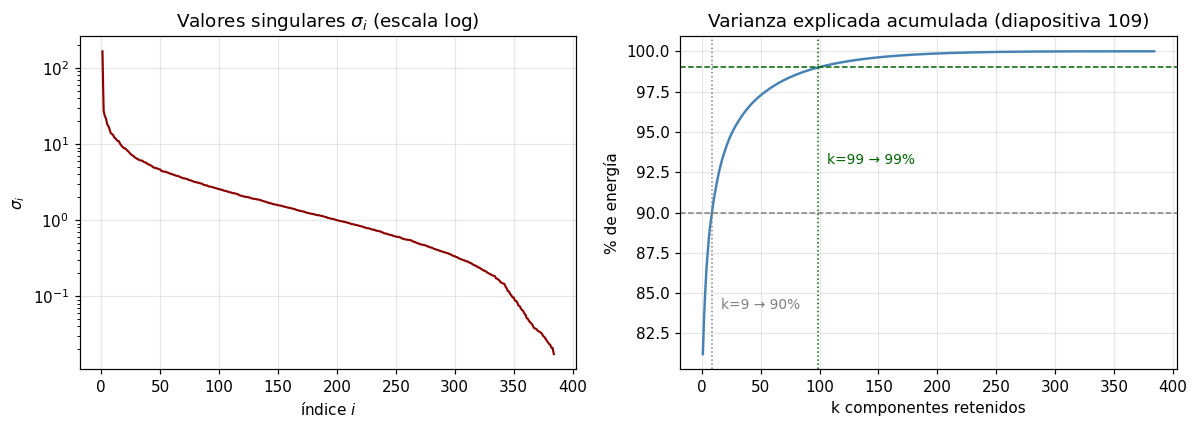

In [17]:
# --- Magnitud de los valores singulares y varianza explicada --------------
# (el scree plot formal y la discusión del "codo" corresponden al Punto 5)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(np.arange(1, len(s) + 1), s, lw=1.4, color="darkred")
axes[0].set_yscale("log")
axes[0].set_title("Valores singulares $\\sigma_i$ (escala log)")
axes[0].set_xlabel("índice $i$")
axes[0].set_ylabel("$\\sigma_i$")
axes[0].grid(alpha=0.3)

axes[1].plot(np.arange(1, len(s) + 1), 100 * varianza_explicada, lw=1.6, color="steelblue")
for umbral, color in [(90, "gray"), (99, "darkgreen")]:
    axes[1].axhline(umbral, ls="--", c=color, lw=1)
    k_min = int(np.searchsorted(varianza_explicada, umbral/100) + 1)
    axes[1].axvline(k_min, ls=":", c=color, lw=1)
    axes[1].text(k_min + len(s)*0.02, umbral - 6, f"k={k_min} → {umbral}%", color=color, fontsize=9)
axes[1].set_title("Varianza explicada acumulada (diapositiva 109)")
axes[1].set_xlabel("k componentes retenidos")
axes[1].set_ylabel("% de energía")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

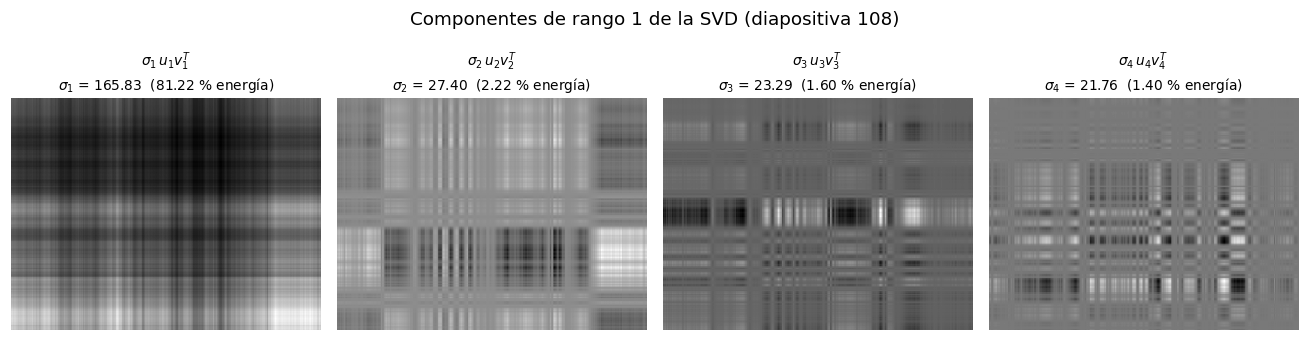

Rango de cada capa individual: [1, 1, 1, 1]

Ortogonalidad de las capas respecto al producto interno de Frobenius:
               capa 1      capa 2      capa 3
  capa 1    2.750e+04  -2.029e-14  -1.147e-14
  capa 2   -2.029e-14   7.510e+02   1.352e-15
  capa 3   -1.147e-14   1.352e-15   5.425e+02

  Fuera de la diagonal el producto interno es 0: las capas son ortogonales entre sí,
  y por eso sus energías sigma_i^2 simplemente se suman.


In [18]:
# --- Las primeras capas de rango 1:  A = suma de sigma_i·u_i·v_i^T ---------
n_capas = 4
fig, axes = plt.subplots(1, n_capas, figsize=(3 * n_capas, 3.2))

for i in range(n_capas):
    capa = s[i] * np.outer(U[:, i], V[:, i])       # sigma_i · u_i · v_i^T
    axes[i].imshow(capa)
    axes[i].set_title(f"$\\sigma_{{{i+1}}}\\,u_{{{i+1}}}v_{{{i+1}}}^T$\n"
                      f"$\\sigma_{{{i+1}}}$ = {s[i]:.2f}  ({100*s[i]**2/energia_total:.2f} % energía)",
                      fontsize=9)
    axes[i].axis("off")

plt.suptitle("Componentes de rango 1 de la SVD (diapositiva 108)", y=1.03)
plt.tight_layout()
plt.show()

print("Rango de cada capa individual:",
      [int(np.linalg.matrix_rank(s[i] * np.outer(U[:, i], V[:, i]))) for i in range(n_capas)])
print()
print("Ortogonalidad de las capas respecto al producto interno de Frobenius:")
print(f"  {'':8}" + " ".join(f"{'capa '+str(j+1):>11}" for j in range(3)))
for i in range(3):
    fila = " ".join(f"{producto_interno_frobenius(s[i]*np.outer(U[:,i], V[:,i]), s[j]*np.outer(U[:,j], V[:,j])):11.3e}"
                    for j in range(3))
    print(f"  capa {i+1:<3}" + fila)
print("\n  Fuera de la diagonal el producto interno es 0: las capas son ortogonales entre sí,")
print("  y por eso sus energías sigma_i^2 simplemente se suman.")

---
### Resultado del Punto 2

Se calculó la SVD completa de $A$ y se verificó, con las herramientas del curso, que:

1. $A = U\Sigma V^{T}$ se cumple con error del orden de la precisión de máquina, medido con la
   **norma de Frobenius** (diapositiva 8).
2. $U$ y $V$ son **ortogonales**: sus columnas forman bases ortonormales, $\langle u_i,u_j\rangle = \delta_{ij}$,
   con ángulos de exactamente 90° entre vectores distintos (diapositivas 6 y 28).
3. Los valores singulares son no negativos y decrecientes, $\sigma_1\ge\dots\ge\sigma_r>0$ (diapositiva 92).
4. Se cumple $Av_i = \sigma_i u_i$, la identidad que resume la interpretación geométrica
   *rotación → escalamiento → rotación* (diapositivas 94–96): el círculo unitario del plano $\{v_1,v_2\}$
   se transforma en una elipse de semiejes $\sigma_1$ y $\sigma_2$.
5. El algoritmo de clase (diagonalizar $A^{T}A$ por el Teorema Espectral, $\sigma_i=\sqrt{\lambda_i}$,
   $u_i = Av_i/\sigma_i$) reproduce el resultado de la librería —tanto en el ejemplo a mano de la
   diapositiva 101 como en la imagen—, con la salvedad numérica de que pierde precisión en la cola.
6. $\|A\|_F^2 = \sum_i \sigma_i^2$, lo que da sentido a la **varianza explicada** de la diapositiva 109.

**El hallazgo que habilita la compresión:** la energía está extremadamente concentrada en los primeros
valores singulares. Aunque el rango de $A$ es prácticamente $\min(m,n)$, basta una fracción pequeña de
componentes para explicar el 99 % de la energía.

### Puente hacia el Punto 3

Truncar la suma en $k$ términos, $A_k = \sum_{i=1}^{k}\sigma_i u_i v_i^{T} = U_k\Sigma_k V_k^{T}$, no es una
heurística: es **la mejor aproximación posible** de rango $k$ en norma de Frobenius
(**Eckart–Young**, diapositiva 108), con error exactamente

$$\|A - A_k\|_F = \sqrt{\sum_{i>k}\sigma_i^{2}}$$

Y esto conecta con las **proyecciones ortogonales** de la diapositiva 33: como las columnas de $U_k$ son
ortonormales, la matriz de proyección sobre el subespacio que generan es $P_k = U_kU_k^{T}$ (el caso
$P = AA^{T}$ de la diapositiva), y se cumple

$$A_k = P_k A = U_kU_k^{T}A$$

O sea que **comprimir la imagen es proyectar ortogonalmente sus columnas** sobre el subespacio de dimensión
$k$ generado por los primeros vectores singulares izquierdos. Por la *propiedad de la mejor aproximación*
(diapositiva 27), esa proyección es el punto de ese subespacio más cercano a la imagen original.

In [19]:
# --- Comprobación del puente: A_k = P_k·A con P_k = U_k·U_k^T -------------
k_demo = 20
U_k = U[:, :k_demo]
P_k = U_k @ U_k.T                                    # matriz de proyección (diapositiva 33)

A_k_truncada  = U_k @ np.diag(s[:k_demo]) @ Vt[:k_demo, :]   # truncando la SVD
A_k_proyectada = P_k @ A                                      # proyectando A

print(f"Con k = {k_demo}:")
print(f"  P_k es simétrica  (P^T = P) : {np.abs(P_k - P_k.T).max():.3e}")
print(f"  P_k es idempotente (P^2 = P): {np.abs(P_k @ P_k - P_k).max():.3e}")
print(f"  max |P_k·A - A_k|           : {np.abs(A_k_proyectada - A_k_truncada).max():.3e}")
print()
print("Error de la aproximación (Eckart-Young, diapositiva 108):")
print(f"  ||A - A_k||_F medido        : {norma_frobenius(A - A_k_truncada):.6f}")
print(f"  sqrt(suma sigma_i^2, i > k) : {np.sqrt(np.sum(s[k_demo:]**2)):.6f}")
print()
print("La igualdad confirma que truncar la SVD = proyectar ortogonalmente sobre el")
print("subespacio generado por {u_1, ..., u_k}. Esto es exactamente el Punto 3.")

Con k = 20:
  P_k es simétrica  (P^T = P) : 0.000e+00
  P_k es idempotente (P^2 = P): 1.943e-16
  max |P_k·A - A_k|           : 4.496e-15

Error de la aproximación (Eckart-Young, diapositiva 108):
  ||A - A_k||_F medido        : 45.443230
  sqrt(suma sigma_i^2, i > k) : 45.443230

La igualdad confirma que truncar la SVD = proyectar ortogonalmente sobre el
subespacio generado por {u_1, ..., u_k}. Esto es exactamente el Punto 3.


---
## Punto 3 — Reconstrucción truncada $A_k$

"Los primeros $k$ componentes" no son los primeros $k$ píxeles: son los $k$ pares $(\sigma_i, u_i, v_i)$,
ya ordenados de mayor a menor $\sigma_i$ por `np.linalg.svd`. Es decir, las $k$ direcciones que más
varianza/información capturan de la imagen. Por venir ordenados así, tomar "los primeros $k$" siempre
recoge las direcciones más relevantes disponibles — de ahí que truncar la SVD sea distinto (y mucho mejor)
que quedarse con cualquier subconjunto arbitrario de $k$ direcciones.

Truncar la SVD en el término $k$-ésimo es entonces quedarnos solo con esas $k$ direcciones:

$$A_k = U(:,1{:}k)\;\Sigma(1{:}k,1{:}k)\;V(:,1{:}k)^{T}$$

Por el **teorema de Eckart–Young** (diapositiva 108), $A_k$ es la mejor aproximación posible de rango $k$
a $A$, con error exacto $\|A-A_k\|_F=\sqrt{\sum_{i>k}\sigma_i^2}$. Guardar $A_k$ cuesta $k(m+n+1)$ números
en vez de los $mn$ de la imagen completa — ahí nace la compresión.

In [20]:
def reconstruir_svd(U, s, Vt, k):
    """A_k = U(:,1:k) @ diag(s(1:k)) @ Vt(1:k,:), la aproximación de rango k a A."""
    return U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]


# Comprobación rápida: con k = r (rango real de A) la reconstrucción debe ser exacta.
A_check = reconstruir_svd(U, s, Vt, r)
print(f"Comprobación con k = r = {r}:  rango(A_k) = {np.linalg.matrix_rank(A_check)}   "
      f"||A - A_k||_F = {norma_frobenius(A - A_check):.2e}  (≈ 0)\n")

valores_k = [1, 5, 10, 20, 50, 100, 200, r]
valores_k = sorted(set(k for k in valores_k if k <= r))
imagenes_k = {k: reconstruir_svd(U, s, Vt, k) for k in valores_k}

# Tabla resumen: error de reconstrucción y costo de guardar A_k para cada k
costo_original = m * n
print(f"{'k':>5} | {'||A-A_k||_F':>12} | {'error relativo':>15} | {'% energía retenida':>19} | {'nº números':>18}")
print("-" * 82)
for k in valores_k:
    error_abs = norma_frobenius(A - imagenes_k[k])
    error_rel = error_abs / norma_frobenius(A)
    energia   = np.sum(s[:k]**2) / np.sum(s**2)          # % de energía retenida (diapositiva 109)
    costo_k   = k * (m + n + 1)                           # U_k + Sigma_k + V_k^T
    print(f"{k:>5} | {error_abs:12.5f} | {100*error_rel:14.2f}% | {100*energia:18.2f}% | "
          f"{costo_k:>8,} ({100*costo_k/costo_original:4.1f}% de A)")


Comprobación con k = r = 384:  rango(A_k) = 384   ||A - A_k||_F = 3.29e-13  (≈ 0)

    k |  ||A-A_k||_F |  error relativo |  % energía retenida |         nº números
----------------------------------------------------------------------------------
    1 |     79.72788 |          43.33% |              81.22% |      897 ( 0.5% de A)
    5 |     65.23643 |          35.46% |              87.43% |    4,485 ( 2.3% de A)
   10 |     56.17974 |          30.53% |              90.68% |    8,970 ( 4.6% de A)
   20 |     45.44323 |          24.70% |              93.90% |   17,940 ( 9.1% de A)
   50 |     30.40862 |          16.53% |              97.27% |   44,850 (22.8% de A)
  100 |     18.19626 |           9.89% |              99.02% |   89,700 (45.6% de A)
  200 |      6.75487 |           3.67% |              99.87% |  179,400 (91.2% de A)
  384 |      0.00000 |           0.00% |             100.00% |  344,448 (175.2% de A)


**Qué dice cada columna:**

- **$\|A-A_k\|_F$**: error absoluto entre la imagen original y la reconstruida (norma de Frobenius). A menor valor, más parecida la reconstrucción a la original.
- **Error relativo**: el error anterior normalizado por $\|A\|_F$, para poder leerlo como un porcentaje independiente de la escala de la imagen.
- **% energía retenida**: qué fracción de $\sum\sigma_i^2$ (la "información total" de la imagen) capturan los primeros $k$ valores singulares. Es la razón por la que el error baja tan rápido al principio: los primeros $\sigma_i$ concentran la mayor parte de la energía.
- **nº números**: cuántos datos hace falta guardar para reconstruir $A_k$ ($k(m+n+1)$, es decir, los $k$ vectores de $U$, los $k$ valores singulares y los $k$ vectores de $V$), comparado contra el tamaño de la imagen original ($mn$ píxeles). Es la columna que realmente mide la compresión: cuantos menos números haga falta guardar frente al total de $A$, mayor la compresión lograda.

¿Por qué se probaron justo esos valores de $k$ (1, 5, 10, 20, 50, 100, 200, r)? Para recorrer todo el
rango de compresión posible: desde compresión extrema ($k=1$, casi todo se pierde) hasta reconstrucción
exacta ($k=r$), pasando por valores intermedios donde ya se recupera la mayor parte de la calidad con
pocos datos — así se puede ver en la tabla en qué punto conviene "quedarse".

Nótese que en $k=r=384$ el costo de guardar $A_k$ (175.2% de $A$) es **mayor** que guardar la imagen
completa, no menor. Esto no es un error: en $k=r$ ya no hay compresión posible, porque se están guardando
*todos* los vectores singulares (equivalente a guardar $A$ completa), más la información extra de tenerla
factorizada en tres piezas ($U_k$, $\Sigma_k$, $V_k^T$) en vez de una sola matriz. La compresión real solo
aparece cuando $k \ll r$: por eso la columna de "nº números" es la que en la práctica decide qué $k$ usar,
no solo el error.

Estas cuatro columnas son las que permiten decidir un $k$ "bueno": uno que retenga casi toda la energía (poco error) usando muchos menos números que la imagen original. Con $k=100$, por ejemplo, se recupera el 99% de la energía guardando menos de la mitad de los datos.

El error baja rápido de $k=1$ a $k\approx20$ y luego se aplana: eso es el "codo" que se verá formalmente
en el scree plot del Punto 5. Con `imagenes_k` ya tenemos todo listo para visualizar y para calcular el ratio de compresión.

---
## Punto 4 — Visualización de $A_k$ vs. la imagen original

Se espera ver a medida que $k$ crece:

- Para $k$ muy chico ($k=1,5$) la imagen se ve **borrosa** y con "bandas": solo se están usando las
  direcciones de mayor varianza, que capturan el contraste general (luz/sombra) pero no el detalle fino
  (bordes, texturas). Es el mismo efecto que se ve en el ejemplo de Einstein del enunciado.
- Para $k$ intermedio ($k=20$–$50$) ya se reconocen los rasgos principales, pero persisten artefactos
  suaves en zonas de alto contraste.
- Para $k$ grande la imagen se vuelve visualmente **indistinguible** de la original, aun sin llegar a
  $k=r$ (reconstrucción exacta) — coherente con que a partir de cierto punto casi no queda energía por
  agregar (columna de "% energía retenida" del Punto 3).

Además de comparar las imágenes lado a lado, es útil visualizar directamente el **error** $|A - A_k|$:
mapea qué píxeles concentra la pérdida de información en cada nivel de compresión.

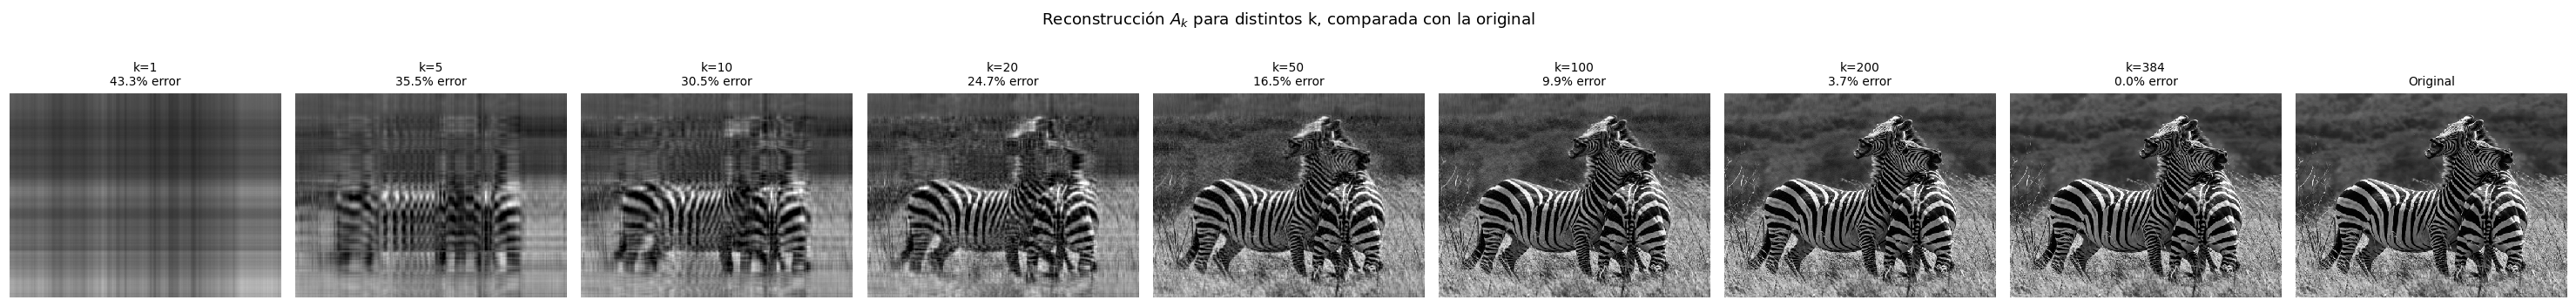

In [21]:
fig, axes = plt.subplots(1, len(valores_k) + 1, figsize=(3 * (len(valores_k) + 1), 3.2))

for ax, k in zip(axes, valores_k):
    error_rel = norma_frobenius(A - imagenes_k[k]) / norma_frobenius(A)
    ax.imshow(np.clip(imagenes_k[k], 0, 1), vmin=0, vmax=1)   # clip: A_k puede salirse levemente de [0,1]
    ax.set_title(f"k={k}\n{100*error_rel:.1f}% error", fontsize=9)
    ax.axis("off")

axes[-1].imshow(A, vmin=0, vmax=1)
axes[-1].set_title("Original", fontsize=9)
axes[-1].axis("off")

plt.suptitle("Reconstrucción $A_k$ para distintos k, comparada con la original", y=1.05)
plt.tight_layout()
plt.show()


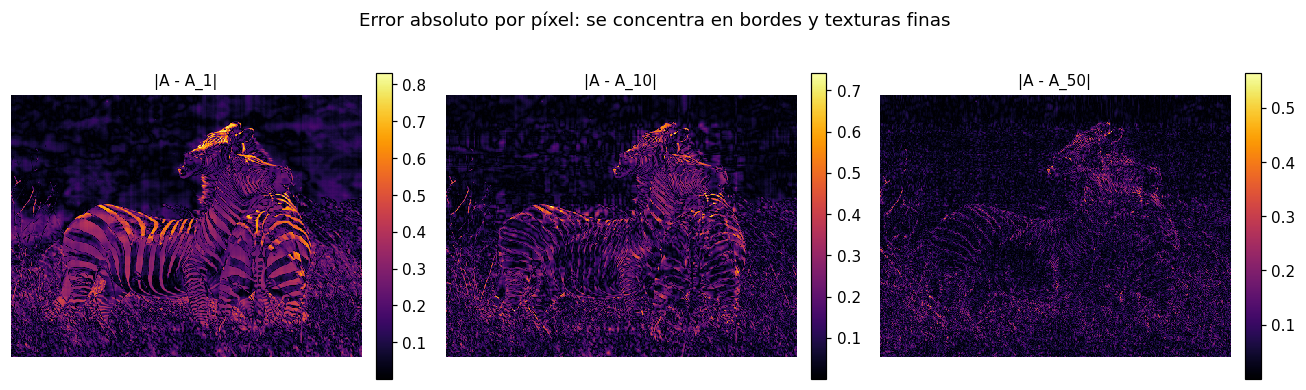

In [22]:
# Mapa de error |A - A_k|: dónde se concentra la pérdida al truncar
k_ejemplo = [1, 10, 50]
fig, axes = plt.subplots(1, len(k_ejemplo), figsize=(4 * len(k_ejemplo), 3.4))

for ax, k in zip(axes, k_ejemplo):
    error_mapa = np.abs(A - imagenes_k[k])
    im = ax.imshow(error_mapa, cmap="inferno")
    ax.set_title(f"|A - A_{k}|", fontsize=10)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle("Error absoluto por píxel: se concentra en bordes y texturas finas", y=1.03)
plt.tight_layout()
plt.show()


El error se concentra en bordes y detalles finos (alta frecuencia espacial), que son justamente las
direcciones asociadas a los $\sigma_i$ más pequeños, las primeras en descartarse al truncar. Esto motiva
el scree plot y el ratio de compresión de los puntos 5 y 6.

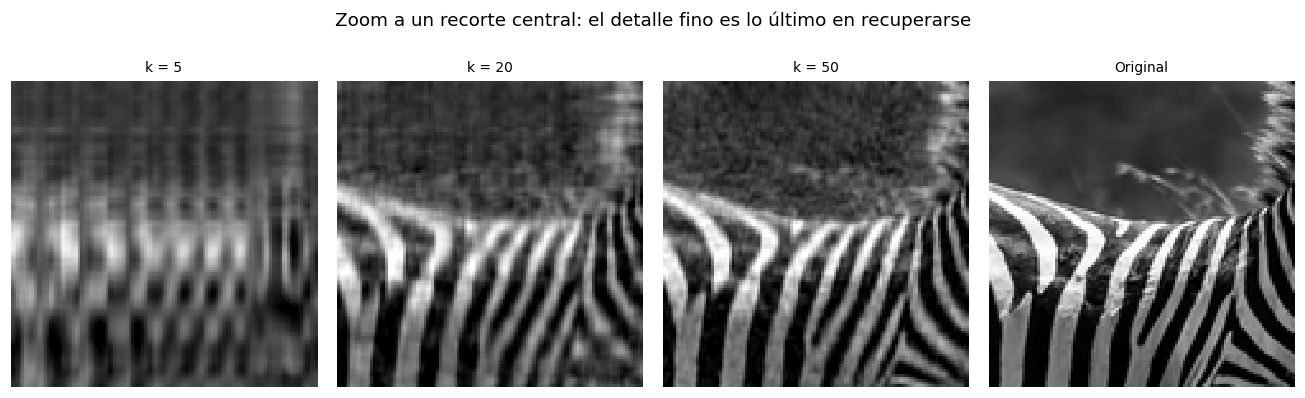

In [23]:
# --- Zoom a una región de detalle (recorte central) para ver el efecto más de cerca ---
i0, i1 = m // 3, m // 3 + min(120, m // 3)   # recorte de una franja horizontal central
j0, j1 = n // 3, n // 3 + min(120, n // 3)   # recorte de una franja vertical central

k_zoom = [5, 20, 50]
fig, axes = plt.subplots(1, len(k_zoom) + 1, figsize=(3 * (len(k_zoom) + 1), 3.4))

for ax, k in zip(axes, k_zoom):
    recorte = np.clip(imagenes_k[k][i0:i1, j0:j1], 0, 1)
    ax.imshow(recorte, vmin=0, vmax=1)
    ax.set_title(f"k = {k}", fontsize=9)
    ax.axis("off")

axes[-1].imshow(A[i0:i1, j0:j1], vmin=0, vmax=1)
axes[-1].set_title("Original", fontsize=9)
axes[-1].axis("off")

plt.suptitle("Zoom a un recorte central: el detalle fino es lo último en recuperarse", y=1.05)
plt.tight_layout()
plt.show()

El zoom a un recorte central confirma lo mismo a nivel de detalle fino: con $k$ chico se pierden texturas, y estas solo reaparecen cuando $k$ crece.